In [ ]:
import pandas as pd

train_df = pd.read_excel(r"C:\Users\yamun\OneDrive\Desktop\Data Analysis\Datasets\train.xlsx")
test_df = pd.read_excel(r"C:\Users\yamun\OneDrive\Desktop\Data Analysis\Datasets\test.xlsx")

X_train = train_df["Reviews"]
X_test = test_df["Reviews"]

y_train = train_df["Sentiment"]
y_test = test_df["Sentiment"]

# clean text
X_train = X_train.fillna("").astype(str)
X_test = X_test.fillna("").astype(str)

# clean labels
y_train = y_train.astype(str).str.lower().str.strip()
y_test = y_test.astype(str).str.lower().str.strip()

# convert labels to numbers
y_train = y_train.map({"pos": 1, "neg": 0})
y_test = y_test.map({"pos": 1, "neg": 0})

# remove any remaining nulls (safety)
y_train = y_train.dropna()
y_test = y_test.dropna()


#TEXT VECTORIZATION
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

#MODEL TRAINING
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

#PREDICTION
y_pred = model.predict(X_test_vec)

#EVALUATION
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.91424


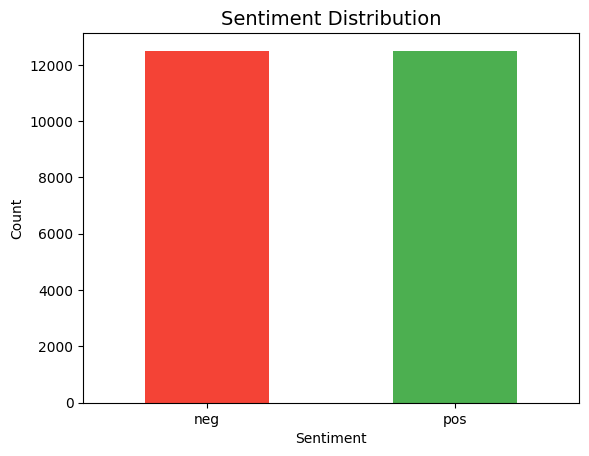

In [42]:
import matplotlib.pyplot as plt

colors = ["#F44336", "#4CAF50"]  # green (positive), red (negative)

train_df["Sentiment"].value_counts().plot(
    kind="bar",
    color=colors
)

plt.title("Sentiment Distribution", fontsize=14)
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

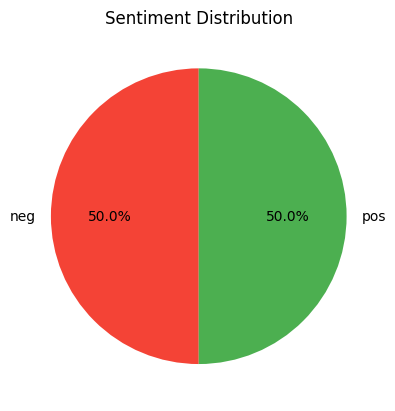

In [44]:
colors = ["#F44336", "#4CAF50"]  # green (positive), red (negative)


train_df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=colors,
    startangle=90
)

plt.title("Sentiment Distribution")
plt.ylabel("")
plt.show()

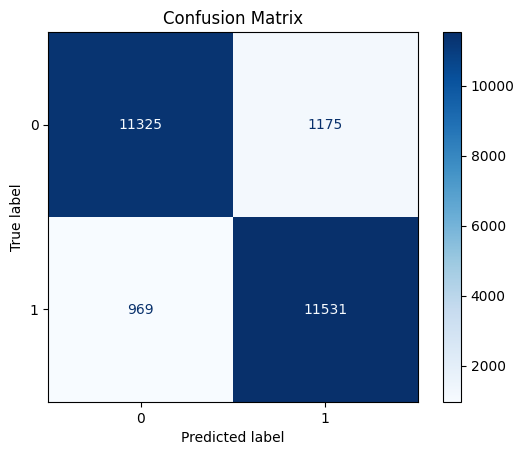

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")  # blue theme

plt.title("Confusion Matrix")
plt.show()

In [46]:
review = ["This movie was absolutely amazing and I loved it"]

# transform using same vectorizer
review_vec = vectorizer.transform(review)

# predict
prediction = model.predict(review_vec)

if prediction[0] == 1:
    print("Positive Review 😊")
else:
    print("Negative Review 😞")

Positive Review 😊


In [49]:
review = ["worst movie ever"]

# transform using same vectorizer
review_vec = vectorizer.transform(review)

# predict
prediction = model.predict(review_vec)

if prediction[0] == 1:
    print("Positive Review 😊")
else:
    print("Negative Review 😞")

Negative Review 😞


In [ ]:
review = ["worst movie ever"]

# transform using same vectorizer
review_vec = vectorizer.transform(review)

# predict
prediction = model.predict(review_vec)

if prediction[0] == 1:
    print("Positive Review 😊")
else:
    print("Negative Review 😞")

In [50]:
print(predict_sentiment("The movie was good but a bit slow"))

Positive 😊


# Insights from Sentiment Analysis

1. The dataset used for this task is balanced, containing an equal number of positive and negative reviews. This helps the model avoid bias towards any one class.

2. The Logistic Regression model achieved an accuracy of around 91%, indicating good performance in classifying text data.

3. The model relies heavily on important keywords such as "good", "excellent", "bad", and "worst" to determine sentiment.

4. Mixed reviews containing both positive and negative words are classified based on dominant words, as the model is a binary classifier.

5. TF-IDF vectorization effectively converts textual data into numerical form by giving more importance to significant words and reducing the impact of common words.

6. The model has limitations in understanding sarcasm, context, and neutral sentiments, which can be improved using advanced NLP models.

# Conclusion

The sentiment analysis model successfully classifies reviews into positive and negative categories with high accuracy. This task demonstrates the effectiveness of machine learning techniques in analyzing textual data and extracting meaningful insights.